# Phase 2.A — YOLO Pose Smoke Test

Goal: understand what ultralytics' pose model returns *before* wrapping it in a filter.

Three questions to answer:
1. Are keypoint coords pixel-space or normalized?
2. How does ultralytics signal "invisible" keypoints?
3. What's the exact ordering of the 17 COCO keypoints?

These answers drive Stage 2's `_apply` logic.

### Notebooks config and imports 

In [6]:
from __future__ import annotations

import time 
from pathlib import Path

import torch 
from ultralytics import YOLO 

import numpy as np

from src.constants import IMAGES_DIR
from src.logger.custom_logger import configure_logger,logger
from src.utils.io import ImageLoader

In [7]:
configure_logger(log_level="INFO")

22:52:17 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-09\22-52-17.log


WindowsPath('C:/Users/rsurs/OneDrive/Documents/cynapse-ai-assignment/logs/2026-05-09/22-52-17.log')

### Loading the model 

In [8]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "yolo11m-pose.pt"
loader = ImageLoader()

In [9]:
logger.info(f"Loading {MODEL_NAME} in {DEVICE}")

t0 = time.perf_counter()

pose_model = YOLO(MODEL_NAME)
pose_model.to(DEVICE)
load_ms = (time.perf_counter() - t0) * 1000 
logger.info(f"Pose model loaded in {load_ms:}.0f ms")
print(f"Model classes:{pose_model.names}")

22:52:17 | INFO     | __main__:<module>:1 | Loading yolo11m-pose.pt in cuda
22:52:17 | INFO     | __main__:<module>:8 | Pose model loaded in 254.1283000027761.0f ms
Model classes:{0: 'person'}


### Examining `pose_model` output

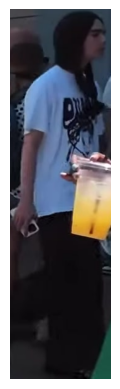

In [16]:
import matplotlib.pyplot as plt 
import cv2 

sample_path = IMAGES_DIR / "crop (33).png"
img = cv2.imread(str(sample_path))
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()


In [17]:
t0 = time.perf_counter()
crop = loader.load(sample_path)
print(f"Crop {crop.crop_id} image shape: {crop.image.shape}")

t0 = time.perf_counter() 
# cold inference (first call GPU warmup)
results = pose_model(crop.image,
                     conf=0.25,
                     verbose=False)

cold_ms = (time.perf_counter() - t0) * 1000 

t0 = time.perf_counter()
results = pose_model(crop.image,
                     conf=0.25,
                     verbose=False)
# warm inference for true steady timing 
warm_ms = (time.perf_counter() - t0) * 1000
logger.info(f"cold inference: {cold_ms:.0f} warm inference: {warm_ms:.0f}")

result = results[0]
print(f"result type: {type(result)}")
print(f"number of detections: {len(result.boxes)}")
print(f"has keypoint detections: {hasattr(result,"keypoints")}")
print(f"type of result keypoints: {type(result.keypoints)}")

23:03:28 | INFO     | src.utils.io:load:61 | Loaded crop (33).png | shape: ((163, 600, 3)) | bytes: 293400
Crop crop (33) image shape: (600, 163, 3)
23:03:29 | INFO     | __main__:<module>:19 | cold inference: 767 warm inference: 49
result type: <class 'ultralytics.engine.results.Results'>
number of detections: 2
has keypoint detections: True
type of result keypoints: <class 'ultralytics.engine.results.Keypoints'>


### Examining keypoint structure

In [20]:
kpts = result.keypoints

print(f"data shape:{kpts.shape}") # data: (x,y,conf) per keypoint, shape:(n_persons,17,3)
print(f"xy shape:{kpts.xy.shape}") # xy: (x,y) shape: (n_persons,17,2)
print(f"xyn shape:{kpts.xyn.shape}") # normalized (x,y) shape: (n_persons,17,2) - [0,1]
print(f"conf shape:{kpts.conf.shape if kpts.conf is not None else 'None'}") # conf per keypoint,shape: (n_persons,17)

# pull the first detected person keypoint to cpu
person_0_data = kpts.data[0].cpu().numpy()
person_0_xyn = kpts.xyn[0].cpu().numpy()
person_0_conf = kpts.conf[0].cpu().numpy()

print("keypoints for person 0:")
print("idx |   x_pix   y_pix   conf  | x_norm   y_norm")
for i in range(17):
    x_p, y_p, c = person_0_data[i]
    x_n, y_n = person_0_xyn[i]
    print(f"{i:>3} | {x_p:>7.1f} {y_p:>7.1f} {c:>5.2f}  | {x_n:>6.3f}  {y_n:>6.3f}")

print(f"\nCrop dimensions for sanity-check: H={crop.height}, W={crop.width}")


data shape:torch.Size([2, 17, 3])
xy shape:torch.Size([2, 17, 2])
xyn shape:torch.Size([2, 17, 2])
conf shape:torch.Size([2, 17])
keypoints for person 0:
idx |   x_pix   y_pix   conf  | x_norm   y_norm
  0 |   148.0    48.6  0.88  |  0.908   0.081
  1 |   148.3    38.2  0.27  |  0.910   0.064
  2 |   136.8    38.5  0.94  |  0.840   0.064
  3 |   129.0    45.0  0.06  |  0.791   0.075
  4 |   104.6    47.6  0.97  |  0.642   0.079
  5 |   126.6   122.6  0.78  |  0.777   0.204
  6 |    67.9   124.7  0.99  |  0.417   0.208
  7 |   131.4   215.4  0.25  |  0.806   0.359
  8 |    34.4   223.1  0.98  |  0.211   0.372
  9 |   142.5   262.8  0.23  |  0.874   0.438
 10 |    22.7   316.9  0.95  |  0.139   0.528
 11 |   116.2   311.7  0.95  |  0.713   0.519
 12 |    80.9   315.5  0.99  |  0.496   0.526
 13 |   114.3   457.1  0.90  |  0.701   0.762
 14 |    93.9   460.2  0.97  |  0.576   0.767
 15 |   100.6   568.4  0.48  |  0.617   0.947
 16 |    93.8   582.3  0.66  |  0.576   0.970

Crop dimensions

In [23]:
COCO_KEYPOINTS = ["nose",
                  "left_eye",
                  "right_eye",
                  'left_ear',
                  'right_ear',
                  'left_shoulder',
                  'right_shoulder',
                  "left_elbow",
                  "right_elbow",
                  "left_wrist",
                  "right_wrist",
                  "left_hip",
                  "right_hip",
                  "left_knee",
                  "right_knee",
                  "left_ankle",
                  "right_ankle"]

print(f"{'idx':>3}  {'name':<16}  {'x_norm':>7}  {'y_norm':>7}  {'conf':>5}")
print("-" * 50)
for i,name in enumerate(COCO_KEYPOINTS):
    x_n,y_n = person_0_xyn[i]
    c = person_0_conf[i]
    visibility = "visible" if c >= 0.5 else "not visible"
    print(f"{i:>3}  {name:<16}  {x_n:>7.3f}  {y_n:>7.3f}  {c:>5.2f}  {visibility}")


idx  name               x_norm   y_norm   conf
--------------------------------------------------
  0  nose                0.908    0.081   0.88  visible
  1  left_eye            0.910    0.064   0.27  not visible
  2  right_eye           0.840    0.064   0.94  visible
  3  left_ear            0.791    0.075   0.06  not visible
  4  right_ear           0.642    0.079   0.97  visible
  5  left_shoulder       0.777    0.204   0.78  visible
  6  right_shoulder      0.417    0.208   0.99  visible
  7  left_elbow          0.806    0.359   0.25  not visible
  8  right_elbow         0.211    0.372   0.98  visible
  9  left_wrist          0.874    0.438   0.23  not visible
 10  right_wrist         0.139    0.528   0.95  visible
 11  left_hip            0.713    0.519   0.95  visible
 12  right_hip           0.496    0.526   0.99  visible
 13  left_knee           0.701    0.762   0.90  visible
 14  right_knee          0.576    0.767   0.97  visible
 15  left_ankle          0.617    0.947   0.48

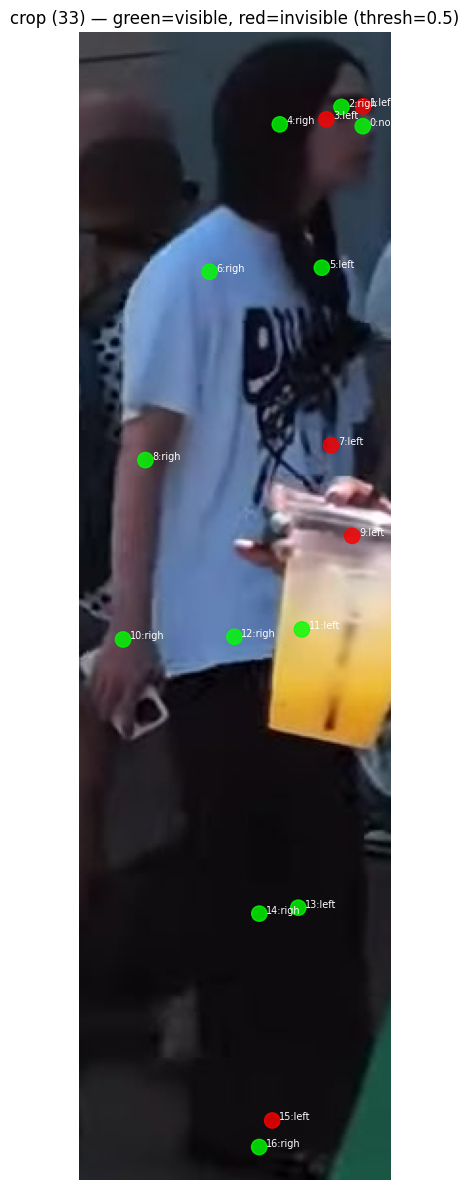

Visible keypoints: 12 / 17


In [24]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(crop.image)

KEYPOINT_THRESHOLD = 0.5  # matches your YAML's keypoint_confidence

for i, name in enumerate(COCO_KEYPOINTS):
    x_p, y_p = person_0_data[i, :2]
    c = person_0_conf[i]
    color = "lime" if c >= KEYPOINT_THRESHOLD else "red"
    ax.add_patch(Circle((x_p, y_p), radius=4, color=color, alpha=0.8))
    ax.annotate(
        f"{i}:{name[:4]}",
        (x_p, y_p),
        fontsize=7,
        color="white",
        xytext=(5, 0),
        textcoords="offset points",
    )

ax.set_title(f"{crop.crop_id} — green=visible, red=invisible (thresh={KEYPOINT_THRESHOLD})")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Visible keypoints: {(person_0_conf >= KEYPOINT_THRESHOLD).sum()} / 17")

# Stage 2 Diagnostic — Investigating the 57% Pose Rejection

Stage 2 rejects 319 of 557 detection-survivors (57%). Two hypotheses:

- **H1 — dataset is genuinely half-body.** Many crops are torso-up, face-only, or otherwise partial-body. Stage 2 correctly filters them.
- **H2 — thresholds are too strict.** `min_leg_kpts: 4` (both knees + both ankles) is stringent. Even visibly full-body people may lose one keypoint to confidence near 0.5.

This notebook eyeballs rejected crops and looks at metric distributions to decide.